In [1]:
using IonSim
using QuantumOptics
using PyPlot

In [12]:
function plot_wigner(final_state)
    rho_motional = ptrace(final_state, 1)

b_fock = FockBasis(20)
rho_fock = DenseOperator(b_fock, rho_motional.data)

x_vec = -4.0:0.1:4.0
p_vec = -4.0:0.1:4.0

W = wigner(rho_fock, x_vec, p_vec)

fig = figure(figsize=(8, 6))
PyPlot.pcolormesh(x_vec, p_vec, W, cmap="RdBu_r", vmin=-0.1, vmax=0.3, shading="nearest")
PyPlot.colorbar(label="Wigner Function W(x, p)")

# Add a marker where the vacuum state (0,0) originally was
PyPlot.plot([0], [0], "w+", markersize=15, markeredgewidth=2, label="Original Vacuum |0>")

PyPlot.xlabel("Position (x)")
PyPlot.ylabel("Momentum (p)")
PyPlot.title("Displaced Motional State")
PyPlot.legend()
PyPlot.grid(color="white", alpha=0.2)

# Display the figure safely in Jupyter (removed show() to prevent the device warning)
display(fig)
end


plot_wigner (generic function with 1 method)

In [18]:
function SDF_apply_with_alpha(angle = 0, time = 50.0, cat_state = false, initial_state = nothing)

    red_angle = (π - 2*angle ) /2
    blue_angle = red_angle + 2 *angle

    if (cat_state)
        println("Preparing cat state superposition...")
        red_angle = -angle
        blue_angle = angle
    end
    trap_freq = 19e5 # 1 MHz trap frequency
    ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -5/2, "e")])
    chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq),selectedmodes=(; z=[1]))

    mode_z = zmodes(chain)[1] # Get the first (and only) Z-mode of the chain
    mode_z.N = 20
    mode_z.shape = [21]

   k_vec = (x̂ + ẑ) / √2
    ϵ_vec = ŷ

    laser_intensity = 1e6 # Adjust this to push the ion faster/slower
    B_field = 1e-13
    trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
    transition_λ = transitionwavelength(ion, ("g", "e"), trap)

    L_red = Laser(Δ = -trap_freq, ϕ=red_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

    L_blue = Laser(Δ = trap_freq, ϕ=blue_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

    trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])

    mode = zmodes(trap)[1]
    println(mode)

    ψ_ion = normalize(ion["g"] -  ion["e"])

    
    ψ_mode = fockstate(mode, 0)
    ψ_initial = ψ_ion ⊗ ψ_mode

    if (initial_state != nothing)
        println("Using provided initial state...")
        ψ_initial = initial_state
    end

    h = hamiltonian(trap, timescale=1e-6, rwa_cutoff=Inf)
    tspan = 0:0.5:time 
    println("Simulating bichromatic displacement...")
    tout, sol = timeevolution.schroedinger_dynamic(tspan, ψ_initial, h)

    final_state = sol[end]

    # ---------------------------------------------------------
# 1. Fundamental Physics Constants
# ---------------------------------------------------------
 hbar = 1.0545718e-34       # Reduced Planck constant (J*s)
 amu = 1.66053906e-27       # Atomic mass unit (kg)
 m_Ca40 = 39.96259 * amu    # Mass of Calcium-40 ion (kg)
 c = 2.99792458e8           # Speed of light (m/s)

# ---------------------------------------------------------
# 2. Your Simulated Experiment Parameters
# ---------------------------------------------------------     
wavelength = transition_λ             # Quadrupole transition wavelength (m)
tspan_end = time * 1e-6              # Total laser interaction time (s)
# ---------------------------------------------------------
# 3. Step-by-Step Calculation
# ---------------------------------------------------------

println("--- VERIFYING DISPLACEMENT PARAMETERS ---")

# Step A: Zero-Point Fluctuation (z_zpf)
# z_zpf = sqrt( ħ / (2 * m * ω_trap) )
omega_trap = 2 * π * trap_freq
z_zpf = sqrt(hbar / (2 * m_Ca40 * omega_trap))
println("Zero-Point Fluctuation (z_zpf) : ", round(z_zpf * 1e9, digits=4), " nm")

# Step B: Wavevector Z-Projection (k_z)
# Your vector: k_vec = (x̂ + ẑ) / √2 
# Therefore, projection onto Z is 1/√2
k_total = 2 * π / wavelength
k_z = k_total / sqrt(2)
println("Z-Projected Wavevector (k_z)   : ", round(k_z, digits=2), " m⁻¹")

# Step C: Lamb-Dicke Parameter (η)
# η = k_z * z_zpf
eta = k_z * z_zpf
println("Lamb-Dicke Parameter (η)       : ", round(eta, digits=4))

# Step D: Effective Rabi Frequency (Ω_eff)
# The geometric coupling factor for a Δm=0 quadrupole transition using your 
# specific k_vec and ϵ_vec vectors results in a scaling reduction of 1/4.
# geometric_factor = 1.0 / 4.0
geometric_factor = 1.0 / ( sqrt(3)) 

# STRETCHED STATE: The CG coefficient is exactly 1.0! 
cg_factor = 1.0 # The Clebsch-Gordan factor for Δm=0 in Ca40

# The true effective Rabi frequency acting on the ion's orbitals
Omega_eff = laser_intensity * geometric_factor * cg_factor
println("Effective Rabi Freq (Ω_eff)    : ", Omega_eff, " rad/s")

# Step E: Displacement Magnitude (|α|)
# |α| = 1/2 * η * Ω_eff * t 
alpha_mag = 0.5 * eta * Omega_eff * tspan_end 

println("-----------------------------------------")
println("FINAL DISPLACEMENT MAGNITUDE (|α| = 0.5 * η * Ω_eff * t) : ", round(alpha_mag, digits=3))
println("-----------------------------------------")
return final_state
end


SDF_apply_with_alpha (generic function with 6 methods)

VibrationalMode(ν=1.9e6, axis=ẑ, N=20)
Simulating bichromatic displacement...
--- VERIFYING DISPLACEMENT PARAMETERS ---
Zero-Point Fluctuation (z_zpf) : 8.1584 nm
Z-Projected Wavevector (k_z)   : 6.09326094e6 m⁻¹
Lamb-Dicke Parameter (η)       : 0.0497
Effective Rabi Freq (Ω_eff)    : 577350.2691896259 rad/s
-----------------------------------------
FINAL DISPLACEMENT MAGNITUDE (|α| = 0.5 * η * Ω_eff * t) : 0.718
-----------------------------------------
Ket(dim=42)
  basis: [⁴⁰Ca ⊗ VibrationalMode(ν=1.9e6, axis=ẑ, N=20)]
   0.5477231297023109 - 0.00023486873079205im
  -0.5476024873532973 + 0.00023484007609539im
  0.00016799831380162 + 0.3916404853096668im
  -0.0001680306587128 - 0.39164051932375377im
 -0.19773017933760295 + 8.488909379807e-5im
  0.19785700922801971 - 8.491328146193e-5im
   -3.502915384738e-5 - 0.08146233605924215im
     3.49551946005e-5 + 0.08146211870133843im
  0.02899814867980394 - 1.247240392457e-5im
 -0.02904163229319038 + 1.248079924618e-5im
     3.99054608649e

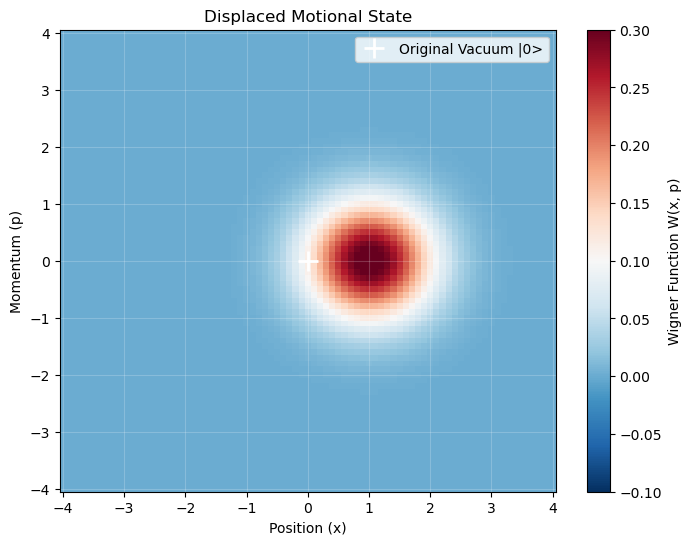

In [19]:
final_state = SDF_apply_with_alpha(0, 50.0, false)

println(final_state)
plot_wigner(final_state)



In [20]:
trap_freq = 19e5 # 1.9 MHz trap frequency
    ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -5/2, "e")])
    chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq), selectedmodes=(; z=[1]))

    mode_z = zmodes(chain)[1] # Get the first (and only) Z-mode of the chain
    mode_z.N = 20
    mode_z.shape = [21]

    k_vec = (x̂ + ẑ) / √2
    ϵ_vec = ŷ

    laser_intensity = 1e6 # Fixed intensity
    B_field = 1e-13
    
    # Pre-build a trap just to grab the transition wavelength
    trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
    transition_λ = transitionwavelength(ion, ("g", "e"), trap)
    mode = zmodes(trap)[1]
    println(mode)
    ψ_ion = normalize(ion["g"] - ion["e"])
    ψ_mode = fockstate(mode, 0)
    ψ_initial = ψ_ion ⊗ ψ_mode

    # 1. Grab the exact mode object used in the simulation (no generic FockBasis!)
sim_mode = zmodes(trap)[1]
a = 0.716 * im 

# 2. Build the displacement operator using the IonSim mode
# IonSim has a built-in displace() method specifically for VibrationalModes
D_motion = IonSim.displace(sim_mode, a)

# 3. Create a "Do Nothing" operator for the ion's spin
I_spin = identityoperator(ion["g"].basis)

 ψ_ion = normalize(ion["g"] -  ion["e"])

# 4. Combine them into a full system operator (Spin ⊗ Motion)
D_system = identityoperator(ψ_ion.basis) ⊗ D_motion

# 5. Apply the operator to the state (The bases now match perfectly!)
displaced_final_state = D_system * ψ_initial

println(displaced_final_state)

VibrationalMode(ν=1.9e6, axis=ẑ, N=20)
Ket(dim=42)
  basis: [⁴⁰Ca ⊗ VibrationalMode(ν=1.9e6, axis=ẑ, N=20)]
     0.54722151763696 + 0.0im
    -0.54722151763696 + 0.0im
                  0.0 + 0.3918106066280634im
                  0.0 - 0.3918106066280634im
  -0.1983691868114632 + 0.0im
   0.1983691868114632 + 0.0im
                  0.0 - 0.08200240843764023im
                  0.0 + 0.08200240843764023im
   0.0293568622206752 + 0.0im
  -0.0293568622206752 + 0.0im
                  0.0 + 0.0094002121409144im
                  0.0 - 0.0094002121409144im
 -0.00274773630415258 + 0.0im
  0.00274773630415258 + 0.0im
                  0.0 - 0.00074359944018383im
                  0.0 + 0.00074359944018383im
   0.0001882379059773 + 0.0im
  -0.0001882379059773 + 0.0im
                  0.0 + 4.492611355992e-5im
                  0.0 - 4.492611355992e-5im
   -1.017212932124e-5 + 0.0im
    1.017212932124e-5 + 0.0im
                  0.0 - 2.19598087043e-6im
                  0.0 + 2.195980870

In [21]:
function SDF_apply_with_alpha(angle = 0, target_alpha = 0.716, cat_state = false, initial_state = nothing, fock_state_n = 0)

    red_angle = (π - 2*angle ) /2
    blue_angle = red_angle + 2 *angle

    if (cat_state)
        # println("Preparing cat state superposi/tion...")
        red_angle = -angle
        blue_angle = angle
    end
    
    trap_freq = 19e5 # 1.9 MHz trap frequency
    ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -5/2, "e")])
    chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq), selectedmodes=(; z=[1]))

    mode_z = zmodes(chain)[1] # Get the first (and only) Z-mode of the chain
    mode_z.N = 20
    mode_z.shape = [21]

    k_vec = (x̂ + ẑ) / √2
    ϵ_vec = ŷ

    laser_intensity = 1e4 # Fixed intensity
    B_field = 1e-13
    
    # Pre-build a trap just to grab the transition wavelength
    trap_pre = Chamber(iontrap=chain, B=B_field, Bhat=ẑ)
    transition_λ = transitionwavelength(ion, ("g", "e"), trap_pre)

    # ---------------------------------------------------------
    # NEW: DYNAMIC TIME CALCULATION VIA WIGNER-ECKART ENGINE
    # ---------------------------------------------------------
    hbar = 1.0545718e-34       
    amu = 1.66053906e-27       
    m_Ca40 = 39.96259 * amu    
    c = 2.99792458e8           

    # 1. Calculate Lamb-Dicke Parameter (η) dynamically
    omega_trap = 2 * π * trap_freq
    z_zpf = sqrt(hbar / (2 * m_Ca40 * omega_trap))
    k_total = 2 * π / transition_λ
    k_z = k_total / sqrt(2)
    eta = k_z * z_zpf

    # 2. Hijack IonSim's internal matrix element calculator
    dummy_laser = Laser(I=laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    Bhat_tuple = (; x=0.0, y=0.0, z=1.0)
    
    # Feed the dummy laser into the exact internal physics engine
    # (Note: Unexported internal functions need the module prefix 'IonSim.')
    Omega_eff_Hz = IonSim.matrixelement(ion, ("g", "e"), laser_intensity, polarization(dummy_laser), wavevector(dummy_laser), Bhat_tuple)
    Omega_eff = Omega_eff_Hz * 2 * π
    # 3. Solve the displacemen formula backward to find exactly how long to leave the lasers on
    target_time_s = (2 * target_alpha) / (eta * Omega_eff)
    target_time_us = target_time_s * 1e6
    # ---------------------------------------------------------

    # Now build the actual lasers and final chamber
    L_red = Laser(Δ = -trap_freq, ϕ=red_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)
    L_blue = Laser(Δ = trap_freq, ϕ=blue_angle, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

    trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])

    mode = zmodes(trap)[1]
    # println(mode)

    ψ_ion = normalize(ion["g"] - ion["e"])
    ψ_mode = fockstate(mode, fock_state_n)
    ψ_initial = ψ_ion ⊗ ψ_mode

    if (initial_state != nothing)
        ψ_initial = initial_state
    end

    h = hamiltonian(trap, timescale=1e-6, rwa_cutoff=Inf)
    
    # Ensure our solver array steps exactly up to our calculated target time
    tspan_array = collect(0:0.5:target_time_us)
    if tspan_array[end] < target_time_us
        push!(tspan_array, target_time_us)
    end

    tout, sol = timeevolution.schroedinger_dynamic(tspan_array, ψ_initial, h)

    final_state = sol[end]
    
    return final_state
end

SDF_apply_with_alpha (generic function with 6 methods)

In [22]:
function protocol(initialstate = nothing, beta = 1, alpha = 0.5)

    beta_state = SDF_apply_with_alpha(0, beta, false, initialstate, 0)
    final_state = SDF_apply_with_alpha(pi/2, alpha, true, beta_state, 0)

    return final_state
end

protocol (generic function with 4 methods)

In [23]:
using LinearAlgebra

function calculate_qcrb(state, state_perturbed, d_alpha::Float64; tol=1e-10)
    
    # 1. Promote pure states (Ket) to density matrices
    rho1 = isa(state, Ket) ? dm(state) : state
    rho2 = isa(state_perturbed, Ket) ? dm(state_perturbed) : state_perturbed
    
    # 2. Extract dense data
    rho_dense_data = dense(rho1).data
    rho_pert_dense_data = dense(rho2).data

    # 3. Finite difference derivative
    drho_data = (rho_pert_dense_data - rho_dense_data) / d_alpha
    
    # 4. Use Hermitian() to guarantee real eigenvalues and speed up diagonalization
    λ, V = LinearAlgebra.eigen(Hermitian(rho_dense_data))
    
    qfi = 0.0
    n = length(λ)
    
    for i in 1:n
        for j in 1:n
            if real(λ[i] + λ[j]) > tol
                # 5. Use @views to prevent memory allocation during column slicing
                @views v_i = V[:, i]
                @views v_j = V[:, j]
                
                drho_ij = dot(v_i, drho_data * v_j)
                qfi += 2 * (abs(drho_ij)^2) / real(λ[i] + λ[j])
            end
        end
    end
    
    qcrb = qfi > 0 ? 1.0 / qfi : Inf
    return qfi, qcrb
end


calculate_qcrb (generic function with 1 method)

Simulating Fock State |2⟩ (Ancilla Readout)...
Beta: 0.01 μs, Fock |2⟩, QCRB: 636.2990073000906
Beta: 0.06 μs, Fock |2⟩, QCRB: 19.072198065227337
Beta: 0.11 μs, Fock |2⟩, QCRB: 6.741257167604776
Beta: 0.16 μs, Fock |2⟩, QCRB: 4.272217935507676
Beta: 0.21 μs, Fock |2⟩, QCRB: 3.8554840703386457
Beta: 0.26 μs, Fock |2⟩, QCRB: 4.849138848861631
Beta: 0.31 μs, Fock |2⟩, QCRB: 9.691295837409804
Beta: 0.36 μs, Fock |2⟩, QCRB: 65.81345037186667
Beta: 0.41 μs, Fock |2⟩, QCRB: 69.24218401193436
Beta: 0.46 μs, Fock |2⟩, QCRB: 6.879158057767632
Beta: 0.51 μs, Fock |2⟩, QCRB: 2.510520032684846
Beta: 0.56 μs, Fock |2⟩, QCRB: 1.4057449263163415
Beta: 0.61 μs, Fock |2⟩, QCRB: 1.014575472546523
Beta: 0.66 μs, Fock |2⟩, QCRB: 0.8868763087092504
Beta: 0.71 μs, Fock |2⟩, QCRB: 0.9233978242237337
Beta: 0.76 μs, Fock |2⟩, QCRB: 1.160716784319002
Beta: 0.81 μs, Fock |2⟩, QCRB: 1.8741168670258006
Beta: 0.86 μs, Fock |2⟩, QCRB: 4.666004558161662
Beta: 0.91 μs, Fock |2⟩, QCRB: 47.967467590349344
Beta: 0.96 μs, 

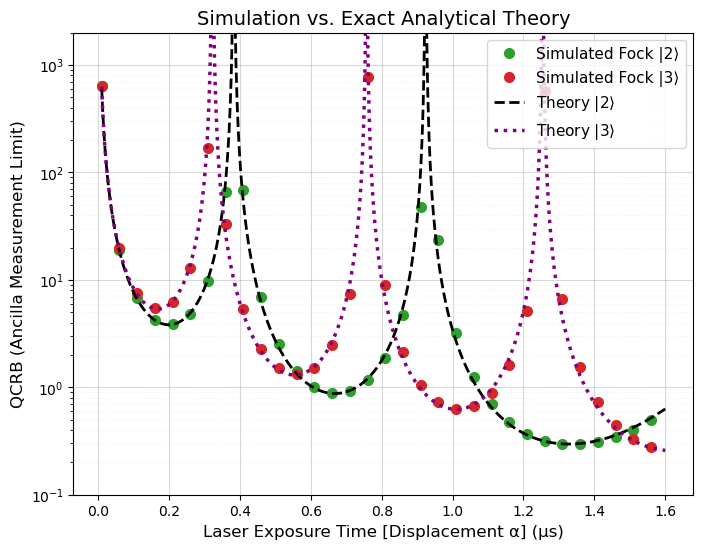

In [24]:
# ---------------------------------------------------------
# QCRB Simulation Loop: Ancilla Qubit Readout (Corrected)
# ---------------------------------------------------------
t_max = 1.6
time_steps = 0.01:0.05:t_max 
states = 2:3 
ψ_ion = normalize(ion["g"] - ion["e"])

# Infinitesimal mathematical signal
d_alpha = 0.01

fig = figure(figsize=(8, 6))
qcrb_matrix = zeros(Float64, length(states), length(time_steps))

# Pre-build the signal operator once to save loop time
sim_mode = zmodes(trap)[1]
D_signal = IonSim.displace(sim_mode, im* d_alpha)
I_spin = identityoperator(ion["g"].basis)
D_system = I_spin ⊗ D_signal

for (i, n) in enumerate(states)
    qcrb_values = Float64[]
    
    ψ_mode = fockstate(mode, n)
    ψ_initial = ψ_ion ⊗ ψ_mode
    
    # APPLY SIGNAL FIRST: Create the perturbed initial state
    ψ_initial_perturbed = D_system * ψ_initial
    
    println("Simulating Fock State |", n, "⟩ (Ancilla Readout)...")
    
    for (j, t) in enumerate(time_steps)
        # 1. Base Trajectory (No Signal)
        sol1 = protocol(ψ_initial, 1, t)
        ancilla_base = ptrace(sol1, 2) 

        finalstate = sol1
        
        # 2. Perturbed Trajectory (Signal happened before SDF readout)
        sol2 = protocol(ψ_initial_perturbed, 1, t)
        ancilla_perturbed = ptrace(sol2, 2)

        finalstate_perturbed = sol2

        # 3. Calculate true Ancilla QCRB
        qfi, qcrb = calculate_qcrb(ancilla_base, ancilla_perturbed, d_alpha)
        push!(qcrb_values, qcrb)
        
        qcrb_matrix[i, j] = qcrb
        println("Beta: ", round(t, digits=2), " μs, Fock |", n, "⟩, QCRB: ", qcrb)
    end

    # Use dots ("o") for the simulation so the theory line can pass through them
    color_choice = n == 2 ? "tab:green" : "tab:red"
    PyPlot.plot(time_steps, qcrb_values, "o", color=color_choice, markersize=7, label="Simulated Fock |$n⟩")
end

# ---------------------------------------------------------
# Analytical Theory Overlay
# ---------------------------------------------------------
# Use a high-resolution X-axis to capture the smooth curves and the exact tip of the spike
alphas_theory = range(0.01, stop=t_max, length=1000)

# Calculate x = 4a^2 to make the Laguerre polynomials readable
x_th = @. 4 * alphas_theory^2

# Theory for |2⟩ (L_2 = 0.5 * (x^2 - 4x + 2))
L2 = @. 0.5 * (x_th^2 - 4 * x_th + 2)
# Formula: exp(4x^2) / (16x^2 * (L_2)^2)
qcrb_theory_2 = @. exp(x_th) / (16 * alphas_theory^2 * L2^2 + 1e-15)

# Theory for |3⟩ (L_3 = (1/6) * (-x^3 + 9x^2 - 18x + 6))
L3 = @. (1/6) * (-x_th^3 + 9 * x_th^2 - 18 * x_th + 6)
# Formula: exp(4x^2) / (16x^2 * (L_3)^2)
qcrb_theory_3 = @. exp(x_th) / (16 * alphas_theory^2 * L3^2 + 1e-15)

# Plot the pure analytical equations
PyPlot.plot(alphas_theory, qcrb_theory_2, "--", color="black", linewidth=2, label=L"Theory $|2\rangle$")
PyPlot.plot(alphas_theory, qcrb_theory_3, ":", color="purple", linewidth=2.5, label=L"Theory $|3\rangle$")

# ---------------------------------------------------------
# Plot Formatting
# ---------------------------------------------------------
PyPlot.yscale("log")
PyPlot.ylim(1e-1, 2e3) # Confidently constrain the Y-axis so infinities don't compress the graph

PyPlot.xlabel("Laser Exposure Time [Displacement α] (μs)", fontsize=12)
PyPlot.ylabel("QCRB (Ancilla Measurement Limit)", fontsize=12)
PyPlot.title("Simulation vs. Exact Analytical Theory", fontsize=14)
PyPlot.legend(loc="upper right", fontsize=11)
PyPlot.grid(which="major", color="gray", alpha=0.3, linestyle="-")
PyPlot.grid(which="minor", color="gray", alpha=0.1, linestyle=":")

display(fig)

Increasing zmode.n to 20 makes the 2, 3 fock state matches with the simulation: Verified that the higher fock states are hitting the wall

Calculating Global Optima for Fock States 0 to 10...
Fock |0⟩ : Optimal α = 0.5, Lowest QCRB = 0.6796
Fock |1⟩ : Optimal α = 0.966, Lowest QCRB = 0.3748
Fock |2⟩ : Optimal α = 1.328, Lowest QCRB = 0.296
Fock |3⟩ : Optimal α = 1.626, Lowest QCRB = 0.2564
Fock |4⟩ : Optimal α = 1.883, Lowest QCRB = 0.2313
Fock |5⟩ : Optimal α = 2.113, Lowest QCRB = 0.2135
Fock |6⟩ : Optimal α = 2.323, Lowest QCRB = 0.2001
Fock |7⟩ : Optimal α = 2.516, Lowest QCRB = 0.1894
Fock |8⟩ : Optimal α = 2.697, Lowest QCRB = 0.1806
Fock |9⟩ : Optimal α = 2.867, Lowest QCRB = 0.1732
Fock |10⟩ : Optimal α = 3.029, Lowest QCRB = 0.1669


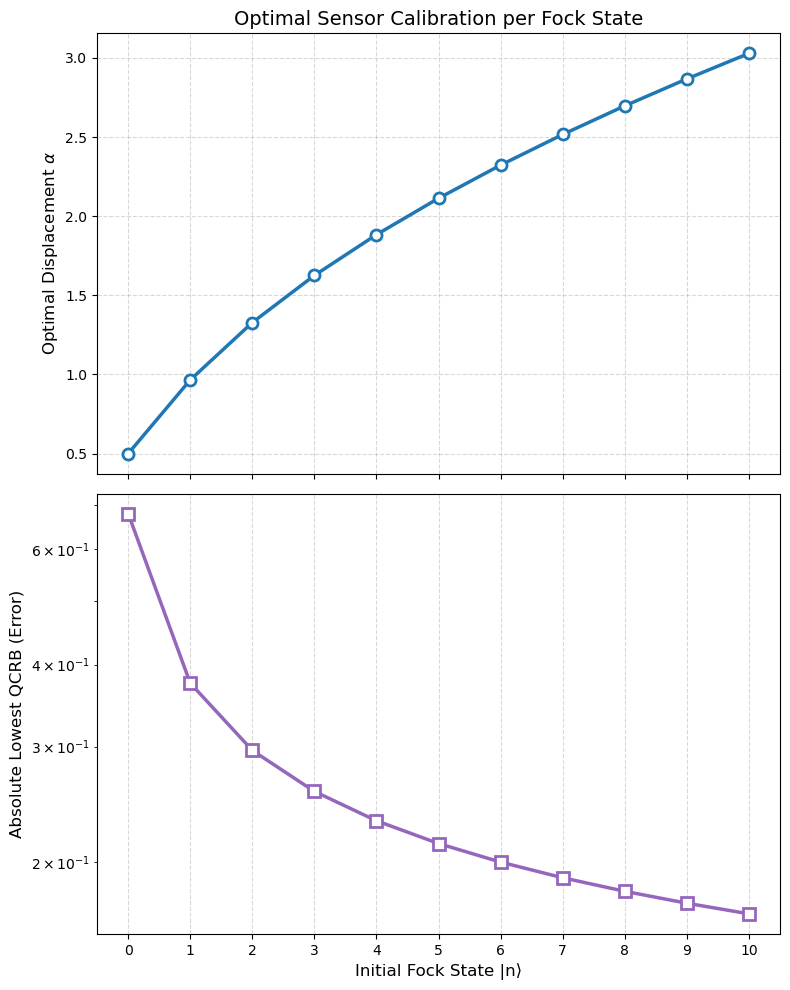

In [27]:
using PyPlot

# ---------------------------------------------------------
# 1. Recursive Laguerre Polynomial Generator
# ---------------------------------------------------------
# This generates L_n(x) for any 'n' without needing hardcoded formulas!
function laguerre(n::Int, x::Float64)
    if n == 0 return 1.0 end
    if n == 1 return 1.0 - x end
    
    L_prev = 1.0
    L_curr = 1.0 - x
    
    for k in 2:n
        L_next = ((2k - 1 - x) * L_curr - (k - 1) * L_prev) / k
        L_prev = L_curr
        L_curr = L_next
    end
    
    return L_curr
end

# ---------------------------------------------------------
# 2. Sweep Parameters
# ---------------------------------------------------------
max_fock = 10
fock_states = 0:max_fock

# Generate a massively high-resolution sweep for Alpha
# We sweep up to 4.0 because optimal alpha grows for higher Fock states
alphas = range(0.01, stop=4.0, length=20000)

optimal_alphas = Float64[]
lowest_qcrbs = Float64[]

println("Calculating Global Optima for Fock States 0 to $max_fock...")

# ---------------------------------------------------------
# 3. Calculate the Global Minimum for each Fock State
# ---------------------------------------------------------
for n in fock_states
    qcrb_curve = zeros(length(alphas))
    
    for (i, a) in enumerate(alphas)
        x_val = 4 * (a^2)
        L_val = laguerre(n, x_val)
        
        # Exact Analytical QCRB Formula
        qcrb_curve[i] = exp(x_val) / (16 * (a^2) * (L_val^2) + 1e-15)
    end
    
    # findmin returns the (minimum_value, index_of_minimum)
    min_val, min_idx = findmin(qcrb_curve)
    
    push!(optimal_alphas, alphas[min_idx])
    push!(lowest_qcrbs, min_val)
    
    println("Fock |$n⟩ : Optimal α = $(round(alphas[min_idx], digits=3)), Lowest QCRB = $(round(min_val, digits=4))")
end

# ---------------------------------------------------------
# 4. Plotting the Results
# ---------------------------------------------------------
# Create a 2-panel plot (Top: Optimal Alpha, Bottom: Lowest QCRB)
fig, (ax1, ax2) = subplots(2, 1, figsize=(8, 10), sharex=true)

# --- Top Panel: Optimal Alpha ---
ax1.plot(fock_states, optimal_alphas, "o-", color="tab:blue", markersize=8, linewidth=2.5, mfc="white", mew=2)
ax1.set_ylabel(L"Optimal Displacement $\alpha$", fontsize=12)
ax1.set_title("Optimal Sensor Calibration per Fock State", fontsize=14)
ax1.grid(color="gray", alpha=0.3, linestyle="--")

# --- Bottom Panel: Lowest QCRB ---
ax2.plot(fock_states, lowest_qcrbs, "s-", color="tab:purple", markersize=8, linewidth=2.5, mfc="white", mew=2)
ax2.set_xlabel("Initial Fock State |n⟩", fontsize=12)
ax2.set_ylabel("Absolute Lowest QCRB (Error)", fontsize=12)
ax2.set_yscale("log") # Log scale shows the scaling advantage perfectly
ax2.grid(color="gray", alpha=0.3, linestyle="--")

# Make the x-axis tick at every integer
ax2.set_xticks(fock_states)

tight_layout()
display(fig)